# Excluding low-firing neurons from analysis

incorporating this into the data loading pipeline

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *

2025-06-10 13:08:56.571410: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-10 13:08:56.580072: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-10 13:08:56.589113: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-10 13:08:56.591954: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-10 13:08:56.600400: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [3]:
# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'

model_dirs = ld.get_immediate_subdirs(all_models_dir)
print(model_dirs)


['Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_231815', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_011809', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225459', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_165543', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_221440', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_175711', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_204320', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212723', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449', 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032739', 'Task_x

In [4]:
# get list of models with performance btwn 60-80%

bad_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.6 and np.mean(trial_perfs) < 0.8:
        bad_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, bad model # {len(bad_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has performance 0.679, bad model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has performance 0.781, bad model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has performance 0.683, bad model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has performance 0.644, bad model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has performance 0.654, bad model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has performance 0.782, bad model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has performance 0.763, bad model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has performance 0.648, bad model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has performance 0.743, bad model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has performance 0.757, bad model # 10
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoi

### start with one model

In [5]:
model_name

'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_125940'

In [8]:
importlib.reload(ld)
neural_data = ld.load_neural_data(model_name, condn_phrase, condn_num, load_rates=True, load_spikes=True, remove_lowfr=True)

No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_125940


In [9]:
neural_data

{'idxs_old': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
         27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
         40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  52,  53,
         54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
         67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
         80,  81,  82,  83,  85,  86,  87,  88,  89,  90,  91,  92,  93,
         94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
        107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
        120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
        133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 145, 146,
        147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
        160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173,
        174, 175, 176, 177, 178, 179, 1

In [10]:
neural_data['rates_data'].shape

(2055, 194, 1000)

In [11]:
neural_data['idxs_old']

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  85,  86,  87,  88,  89,  90,  91,  92,  93,
        94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106,
       107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119,
       120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132,
       133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 167, 168, 169, 170, 171, 172, 173,
       174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 18

In [11]:
lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=2)
lowfr_idx

array([  0,  51,  84, 144, 166, 195])

### look at model with v low fr

In [12]:
model_name = 'Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191340'

In [34]:
importlib.reload(ld)
neural_data = ld.load_neural_data(model_name, condn_phrase, condn_num, load_rates=True, load_spikes=True, remove_lowfr=True)

In [35]:
neural_data

{'idxs_old': array([  0,   1,   2,   3,   4,   5,   8,  10,  12,  13,  15,  19,  20,
         21,  24,  26,  27,  28,  29,  30,  31,  32,  34,  36,  39,  40,
         41,  42,  43,  47,  48,  49,  52,  57,  60,  64,  65,  66,  68,
         69,  72,  73,  74,  75,  77,  78,  79,  80,  82,  83,  86,  87,
         88,  89,  90,  92,  93,  95,  96,  97, 100, 101, 103, 104, 106,
        109, 110, 111, 112, 115, 116, 117, 118, 119, 120, 121, 122, 123,
        124, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
        138, 139, 140, 143, 145, 146, 147, 149, 150, 152, 154, 157, 160,
        161, 162, 164, 167, 168, 169, 170, 171, 175, 177, 179, 180, 181,
        182, 183, 184, 185, 187, 188, 189, 192, 194, 195, 196, 198, 199]),
 'neuron_idxs': array([  6,   7,   9,  11,  14,  16,  17,  18,  22,  23,  25,  33,  35,
         37,  38,  44,  45,  46,  50,  51,  53,  54,  55,  56,  58,  59,
         61,  62,  63,  67,  70,  71,  76,  81,  84,  85,  91,  94,  98,
         99, 102, 105,

In [18]:
neural_data['spk_df']

,cell_id,trial_id,cell_type,spk_times,model_name,delay
0,0,0,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
1,1,0,inh,"[1923.0, 2588.0, 6356.0, 8932.0, 10397.0, 1155...",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
2,2,0,inh,"[0.0, 551.0, 1112.0, 1855.0, 2463.0, 3192.0, 3...",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
3,3,0,exc,"[0.0, 13776.0, 15177.0, 16283.0, 16914.0, 1772...",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
4,4,0,exc,"[1, 0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
...,...,...,...,...,...,...
199994,194,999,exc,"[7730.0, 9287.0, 14235.0, 17281.0, 18932.0, 24...",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
199995,195,999,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
199996,196,999,exc,"[0.0, 17556.0]",Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150
199998,198,999,exc,[0.0],Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_...,150


In [19]:
np.unique(neural_data['spk_df']['cell_id'])

array([  0,   1,   2,   3,   4,   5,   8,  10,  12,  13,  15,  19,  20,
        21,  24,  26,  27,  28,  29,  30,  31,  32,  34,  36,  39,  40,
        41,  42,  43,  47,  48,  49,  52,  57,  60,  64,  65,  66,  68,
        69,  72,  73,  74,  75,  77,  78,  79,  80,  82,  83,  86,  87,
        88,  89,  90,  92,  93,  95,  96,  97, 100, 101, 103, 104, 106,
       109, 110, 111, 112, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
       138, 139, 140, 143, 145, 146, 147, 149, 150, 152, 154, 157, 160,
       161, 162, 164, 167, 168, 169, 170, 171, 175, 177, 179, 180, 181,
       182, 183, 184, 185, 187, 188, 189, 192, 194, 195, 196, 198, 199])

In [37]:
np.unique(neural_data['spk_df']['cell_id'][neural_data['spk_df']['cell_type']== 'inh'])

array([  1,   2,   8,  10,  15,  27,  31,  40,  47,  48,  49,  57,  64,
        68,  79,  89, 100, 103, 111, 133, 134, 135, 140, 143, 147, 149,
       167, 180, 183, 184])

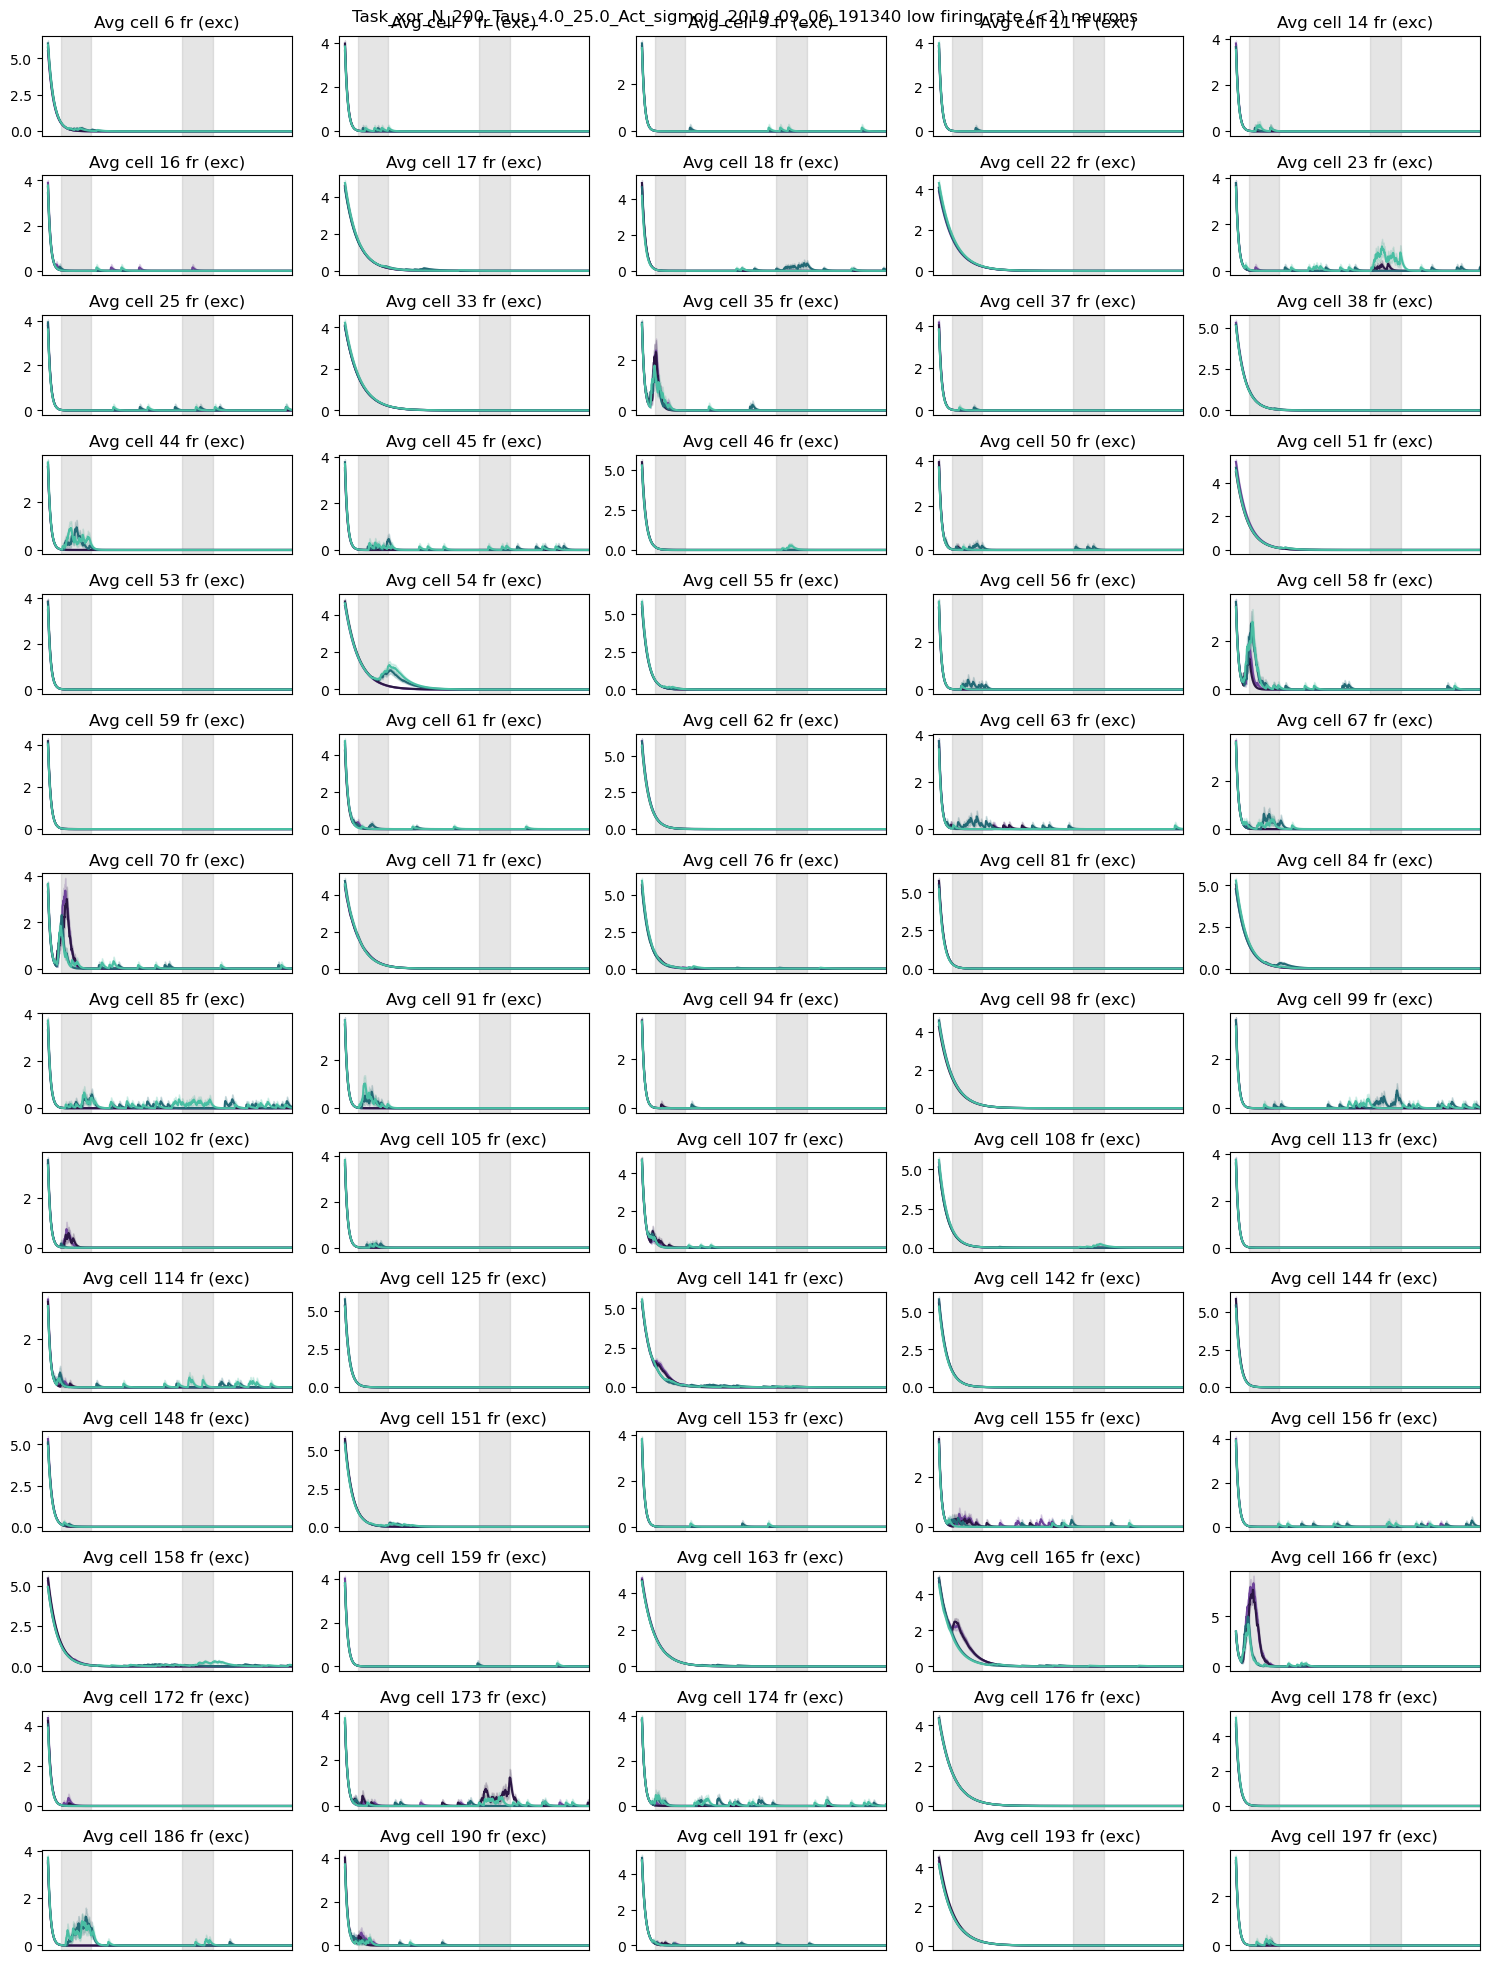

In [33]:
threshold = 2

lowfr_idx = calc_lowfr_neurons(spk_df, times_spk, threshold=threshold)

fig, axs = plt.subplots(14,5, figsize=(15, 20))
axs = axs.flatten()
for i, i_neuron in enumerate(lowfr_idx):
    sn.plot_neuron_rates(model_name, i_neuron, condn_phrase, condn_num, rates_data=rates_data, ax=axs[i])
    # turn off legend
    axs[i].legend().set_visible(False)
    axs[i].set_ylabel('')
    axs[i].set_xlabel('')
    axs[i].set_xticks([])
plt.suptitle(f'{model_name} low firing rate (<{threshold}) neurons')
plt.tight_layout()
plt.show()

In [16]:
_,_,rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num, load_rates=True, remove_lowfr=False)

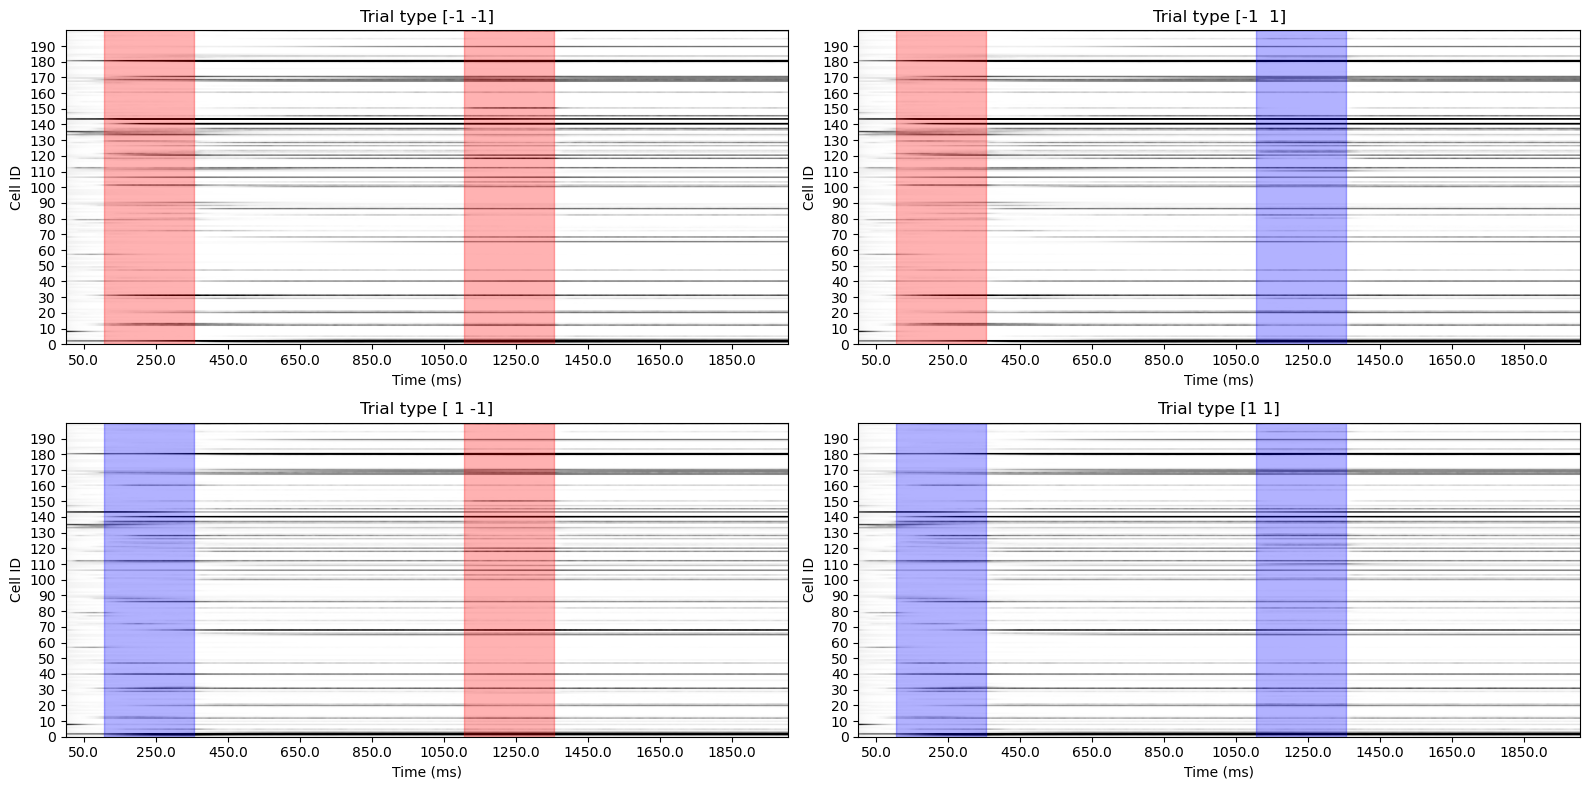

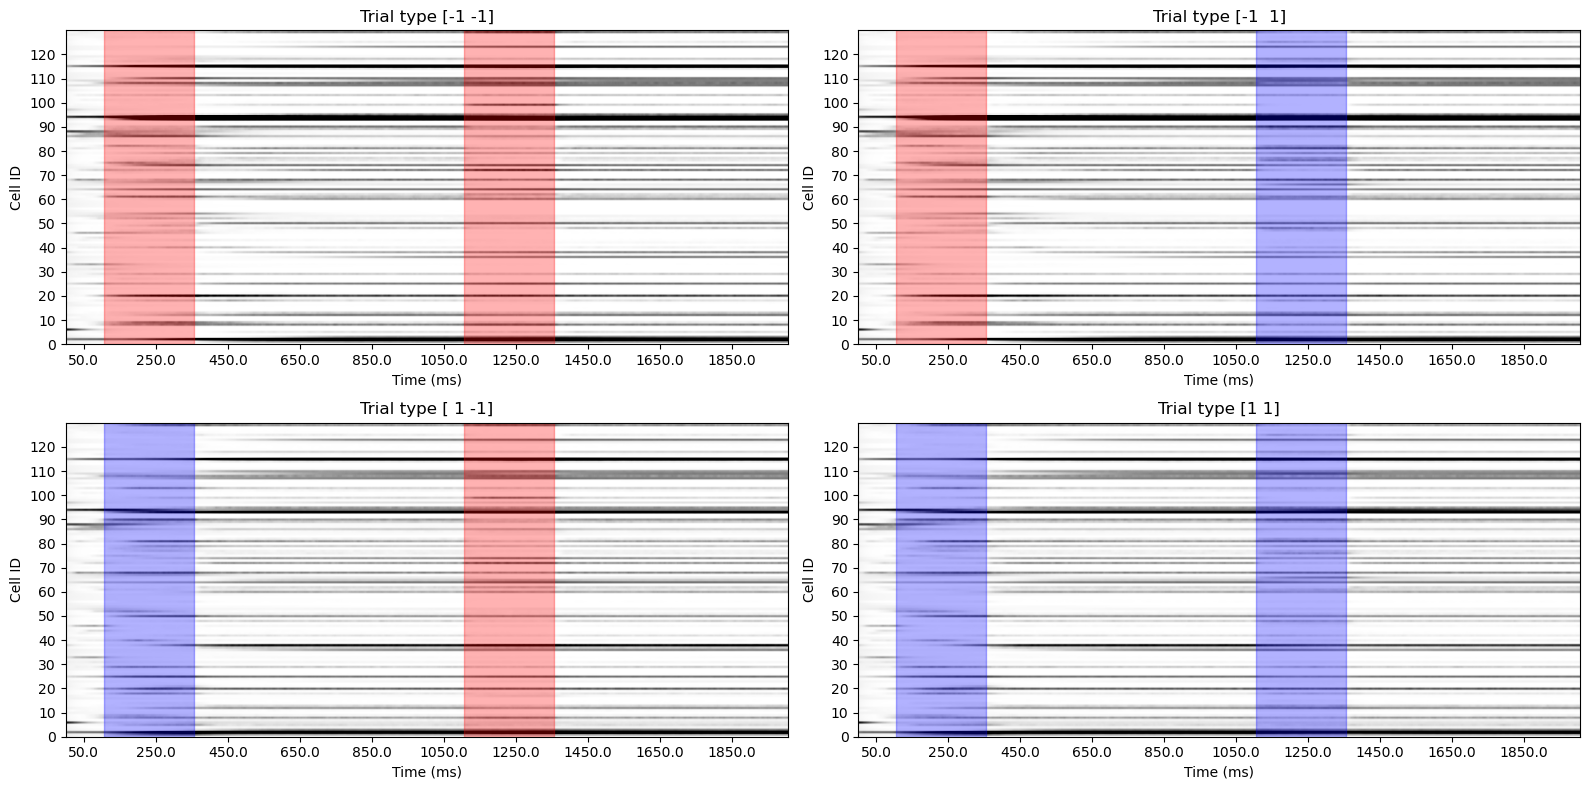

In [17]:
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, rates_data)
sn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, neural_data['rates_data'])

## run thru bad models

/tmp/ipykernel_1207057/665263137.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


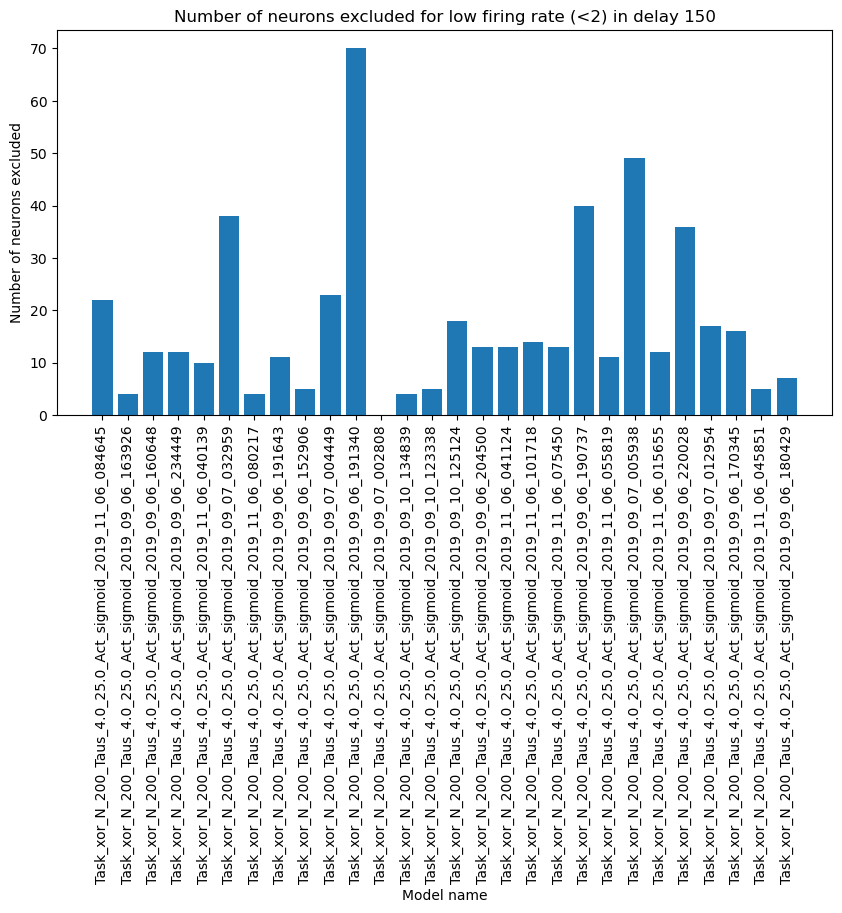

In [39]:
threshold = 2

n_exclude_bad = np.zeros(len(bad_models))
for i, model_name in enumerate(bad_models):
    exclude_idxs = ld.load_lowfr_idxs(model_name, condn_phrase, condn_num, threshold=threshold)
    n_exclude_bad[i] = len(exclude_idxs)
plt.figure(figsize=(10,5))
plt.bar(np.arange(len(bad_models)), n_exclude_bad)
plt.xticks(np.arange(len(bad_models)), bad_models, rotation=90)
plt.ylabel('Number of neurons excluded')
plt.xlabel('Model name')
plt.title(f'Number of neurons excluded for low firing rate (<{threshold}) in {condn_phrase} {condn_num}')
plt.tight_layout()
plt.show()

## run thru good models

In [40]:
# get list of models with performance btwn 95-100%

good_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.95:
        good_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, good model # {len(good_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818 has performance 0.973, good model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727 has performance 0.958, good model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328 has performance 0.988, good model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_010848 has performance 0.991, good model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_140926 has performance 0.991, good model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816 has performance 0.973, good model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_040845 has performance 0.979, good model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_183907 has performance 0.959, good model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_200219 has performance 0.995, good model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_120653 has performance 0.982, good model # 10
Task_xor_N_200_Taus_4.0_25.0_

No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_212818
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_225727
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_174328
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_010848
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_10_140926
No files found with keywords ['lowfr', 'delay150', '2'] in /home/nuttidalab/Documents/renee/all_DMS_models/Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_193816
No f

/tmp/ipykernel_1207057/3526618995.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


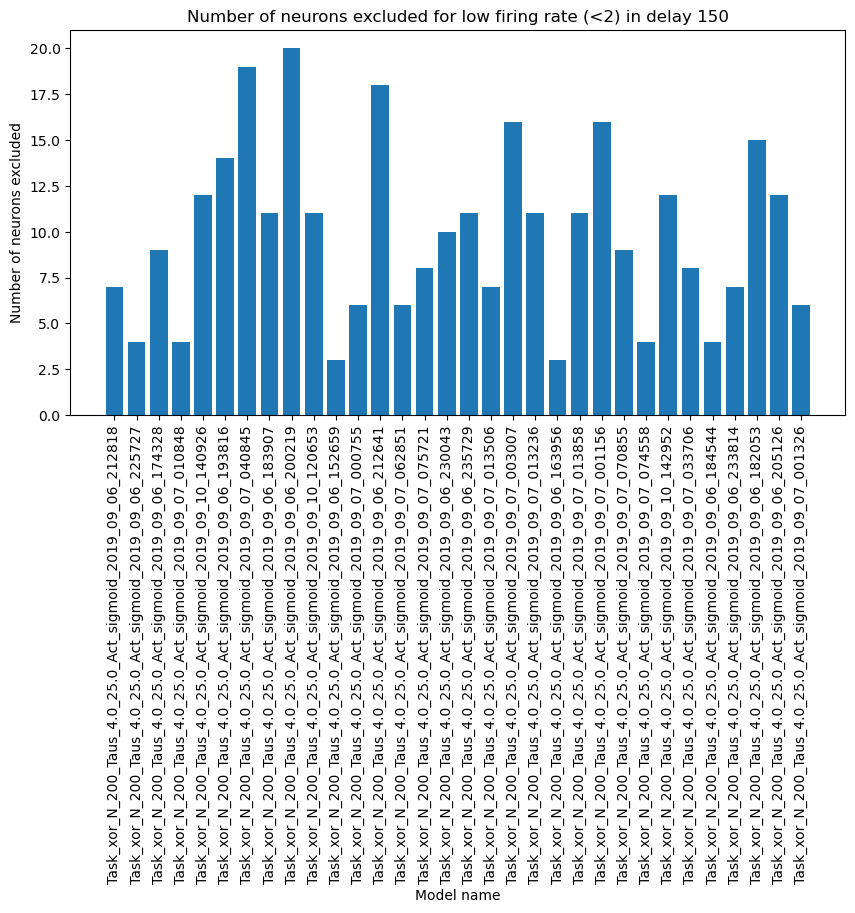

In [41]:
threshold = 2
n_exclude_good = np.zeros(len(good_models))
for i, model_name in enumerate(good_models):
    exclude_idxs = ld.load_lowfr_idxs(model_name, condn_phrase, condn_num, threshold=threshold)
    n_exclude_good[i] = len(exclude_idxs)
plt.figure(figsize=(10,5))
plt.bar(np.arange(len(good_models)), n_exclude_good)
plt.xticks(np.arange(len(good_models)), good_models, rotation=90)
plt.ylabel('Number of neurons excluded')
plt.xlabel('Model name')
plt.title(f'Number of neurons excluded for low firing rate (<{threshold}) in {condn_phrase} {condn_num}')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1207057/1504511021.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


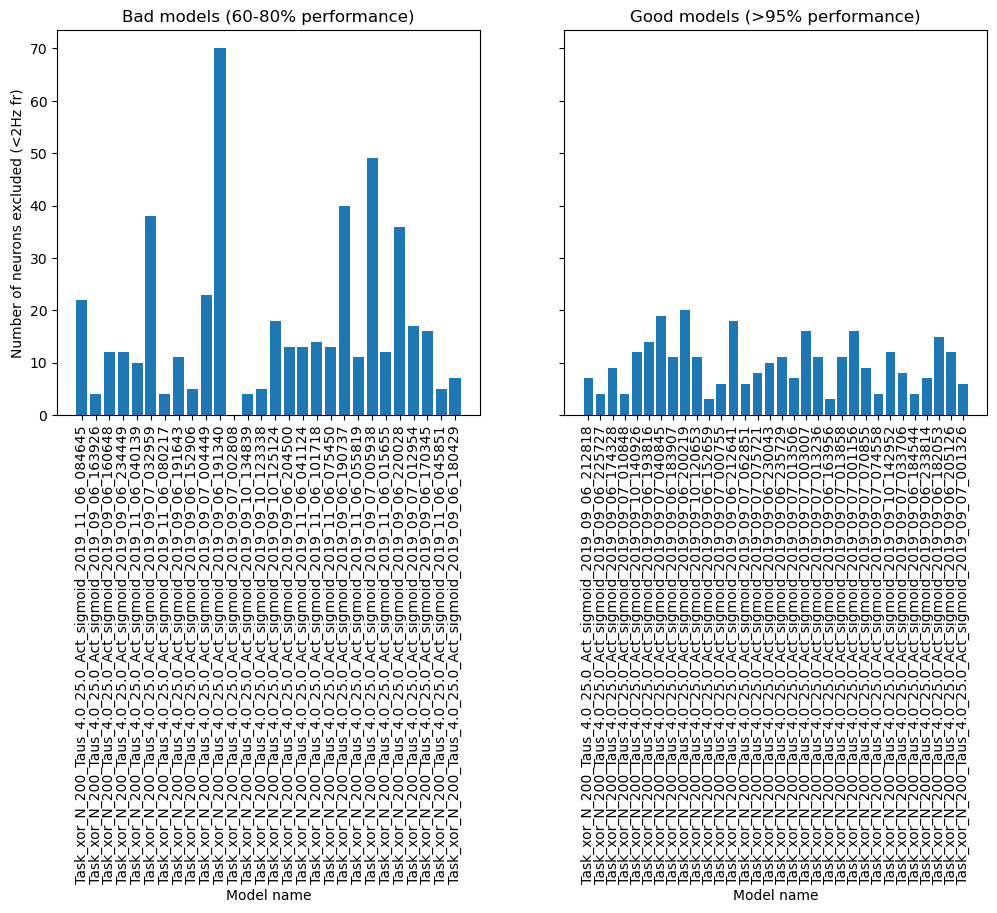

In [47]:
fig, axs = plt.subplots(1,2, figsize=(12,5), sharey=True)
axs[0].bar(np.arange(len(bad_models)), n_exclude_bad)
axs[0].set_xticks(np.arange(len(bad_models)))
axs[0].set_xticklabels(bad_models, rotation=90)
axs[0].set_ylabel('Number of neurons excluded (<2Hz fr)')
axs[0].set_xlabel('Model name')
axs[0].set_title(f'Bad models (60-80% performance)')

axs[1].bar(np.arange(len(good_models)), n_exclude_good)
axs[1].set_xticks(np.arange(len(good_models)))
axs[1].set_xticklabels(good_models, rotation=90)
axs[1].set_xlabel('Model name')
axs[1].set_title(f'Good models (>95% performance)')
plt.tight_layout()
plt.show()

### do stats

In [4]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

# get all of the good models and their performances
good_models, good_perfs = ld.get_models_by_perf(low_cutoff=0.95, high_cutoff=np.inf, 
                                              condn_phrase=condn_phrase, condn_num=condn_num)

bad_models, bad_perfs = ld.get_models_by_perf(low_cutoff=0.6, high_cutoff=0.8, 
                                              condn_phrase=condn_phrase, condn_num=condn_num)

Found 32 models with performance between 0.95 and inf
Found 28 models with performance between 0.6 and 0.8


In [6]:
threshold = 2
n_exclude_good = np.zeros(len(good_models))
n_exclude_bad = np.zeros(len(bad_models))
for i, model_name in enumerate(good_models):
    exclude_idxs = ld.load_lowfr_idxs(model_name, condn_phrase, condn_num, threshold=threshold)
    n_exclude_good[i] = len(exclude_idxs)
for i, model_name in enumerate(bad_models):
    exclude_idxs = ld.load_lowfr_idxs(model_name, condn_phrase, condn_num, threshold=threshold)
    n_exclude_bad[i] = len(exclude_idxs)

Mann-Whitney U test: U-statistic=318.5, p-value=0.0553378052785614


/tmp/ipykernel_2301764/872266096.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([n_exclude_good, n_exclude_bad], labels=['Good Models', 'Bad Models'])


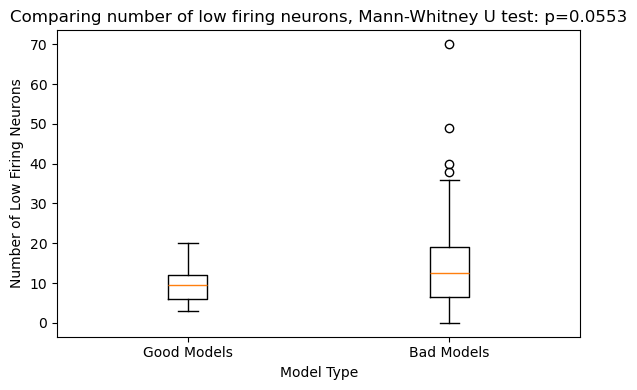

In [7]:
# plot as boxplots with mann-whitney U test
plt.figure(figsize=(6,4))
plt.boxplot([n_exclude_good, n_exclude_bad], labels=['Good Models', 'Bad Models'])

# stats
from scipy.stats import mannwhitneyu
stat, p_value = mannwhitneyu(n_exclude_good, n_exclude_bad)
print(f'Mann-Whitney U test: U-statistic={stat}, p-value={p_value}')
plt.title(f'Comparing number of low firing neurons, Mann-Whitney U test: p={p_value:.4f}')
plt.xlabel('Model Type')
plt.xticks([1, 2], ['Good Models', 'Bad Models'])
plt.ylabel('Number of Low Firing Neurons')
plt.tight_layout()
plt.show()